# Visualization export (`VisualizationExporter`)

This notebook demonstrates [`VisualizationExporter`](../../src/congressgov/services/export/visualization.py) in `congressgov.services.export`.

Install optional dependencies:

```bash
pip install "congressgov[export,viz]"
# from source: pip install -e ".[export,viz]"
```

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from congressgov.services.export import ExportConfig, VisualizationExporter

# Charts are written here, then displayed inline in the notebook
OUTPUT_DIR = Path("output/visualization")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

config = ExportConfig(flatten_nested=True)
viz = VisualizationExporter(config=config)

print("Available plot types:", viz.get_available_plots())

Available plot types: ['bill_types', 'timeline', 'committee_activity', 'member_activity', 'custom', 'dashboard']


## Sample data

`VisualizationExporter` accepts a **pandas DataFrame** or any iterable of Pydantic models / dicts (converted via `PandasIntegration`). Column names are detected heuristically:

| Plot | Expected columns |
|------|------------------|
| `plot_bill_types` | `type` |
| `plot_timeline` | a column containing `date` or `time` |
| `plot_committee_activity` | `committee` + date column |
| `plot_member_activity` | `member` or `sponsor` |

In [2]:
bills_df = pd.DataFrame(
    [
        {"type": "hr", "introduced_date": "2023-01-15", "committee": "Judiciary", "sponsor": "Smith"},
        {"type": "hr", "introduced_date": "2023-02-01", "committee": "Judiciary", "sponsor": "Jones"},
        {"type": "s", "introduced_date": "2023-02-10", "committee": "Finance", "sponsor": "Smith"},
        {"type": "hr", "introduced_date": "2023-03-05", "committee": "Finance", "sponsor": "Lee"},
        {"type": "hjres", "introduced_date": "2023-03-20", "committee": "Rules", "sponsor": "Jones"},
        {"type": "s", "introduced_date": "2023-04-01", "committee": "Judiciary", "sponsor": "Lee"},
        {"type": "hr", "introduced_date": "2023-04-15", "committee": "Rules", "sponsor": "Smith"},
        {"type": "s", "introduced_date": "2023-05-01", "committee": "Finance", "sponsor": "Jones"},
    ]
)
bills_df

,type,introduced_date,committee,sponsor
0,hr,2023-01-15,Judiciary,Smith
1,hr,2023-02-01,Judiciary,Jones
2,s,2023-02-10,Finance,Smith
3,hr,2023-03-05,Finance,Lee
4,hjres,2023-03-20,Rules,Jones
5,s,2023-04-01,Judiciary,Lee
6,hr,2023-04-15,Rules,Smith
7,s,2023-05-01,Finance,Jones


In [3]:
def show_saved(path: Path, width: int = 900) -> None:
    """Display a chart saved by VisualizationExporter (figures are closed after save)."""
    display(Image(filename=str(path), width=width))

## Bill type distribution

`plot_bill_types` builds a bar chart from the `type` column.

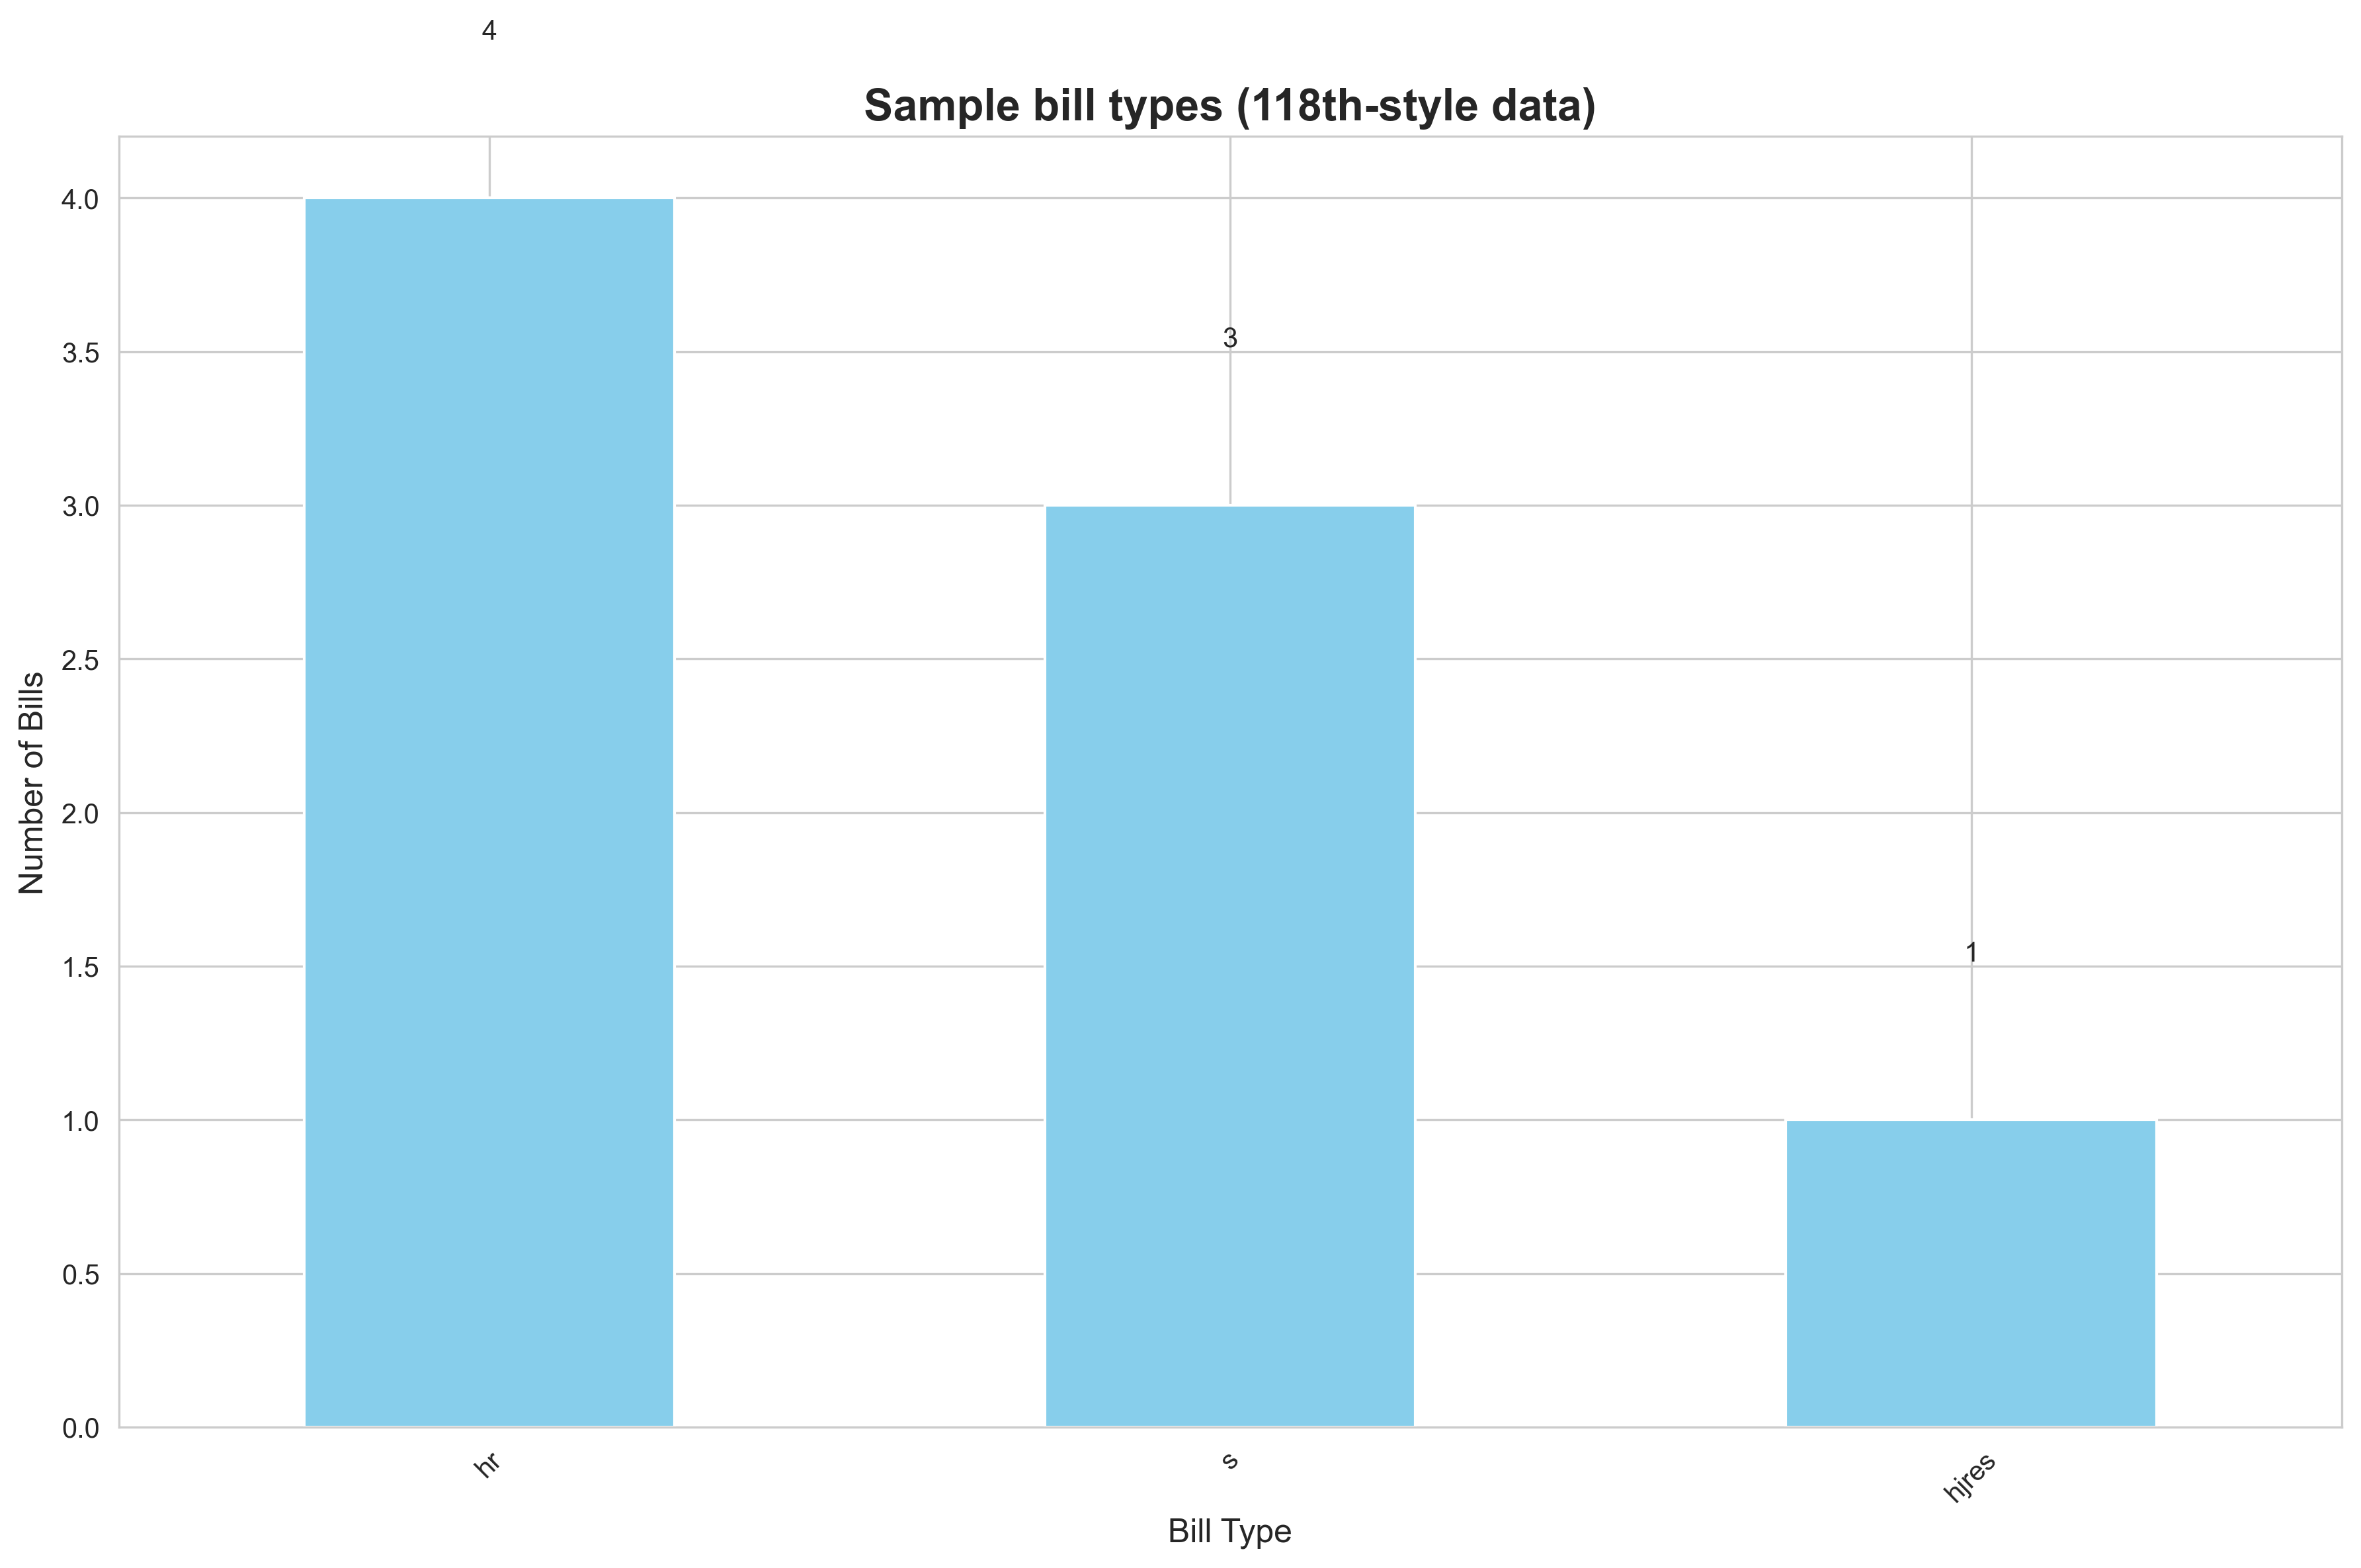

In [4]:
bill_types_path = OUTPUT_DIR / "bill_types.png"
viz.plot_bill_types(
    bills_df,
    bill_types_path,
    title="Sample bill types (118th-style data)",
    show_values=True,
)
show_saved(bill_types_path)

## Introduction timeline

`plot_timeline` groups records by date (first column whose name contains `date` or `time`).

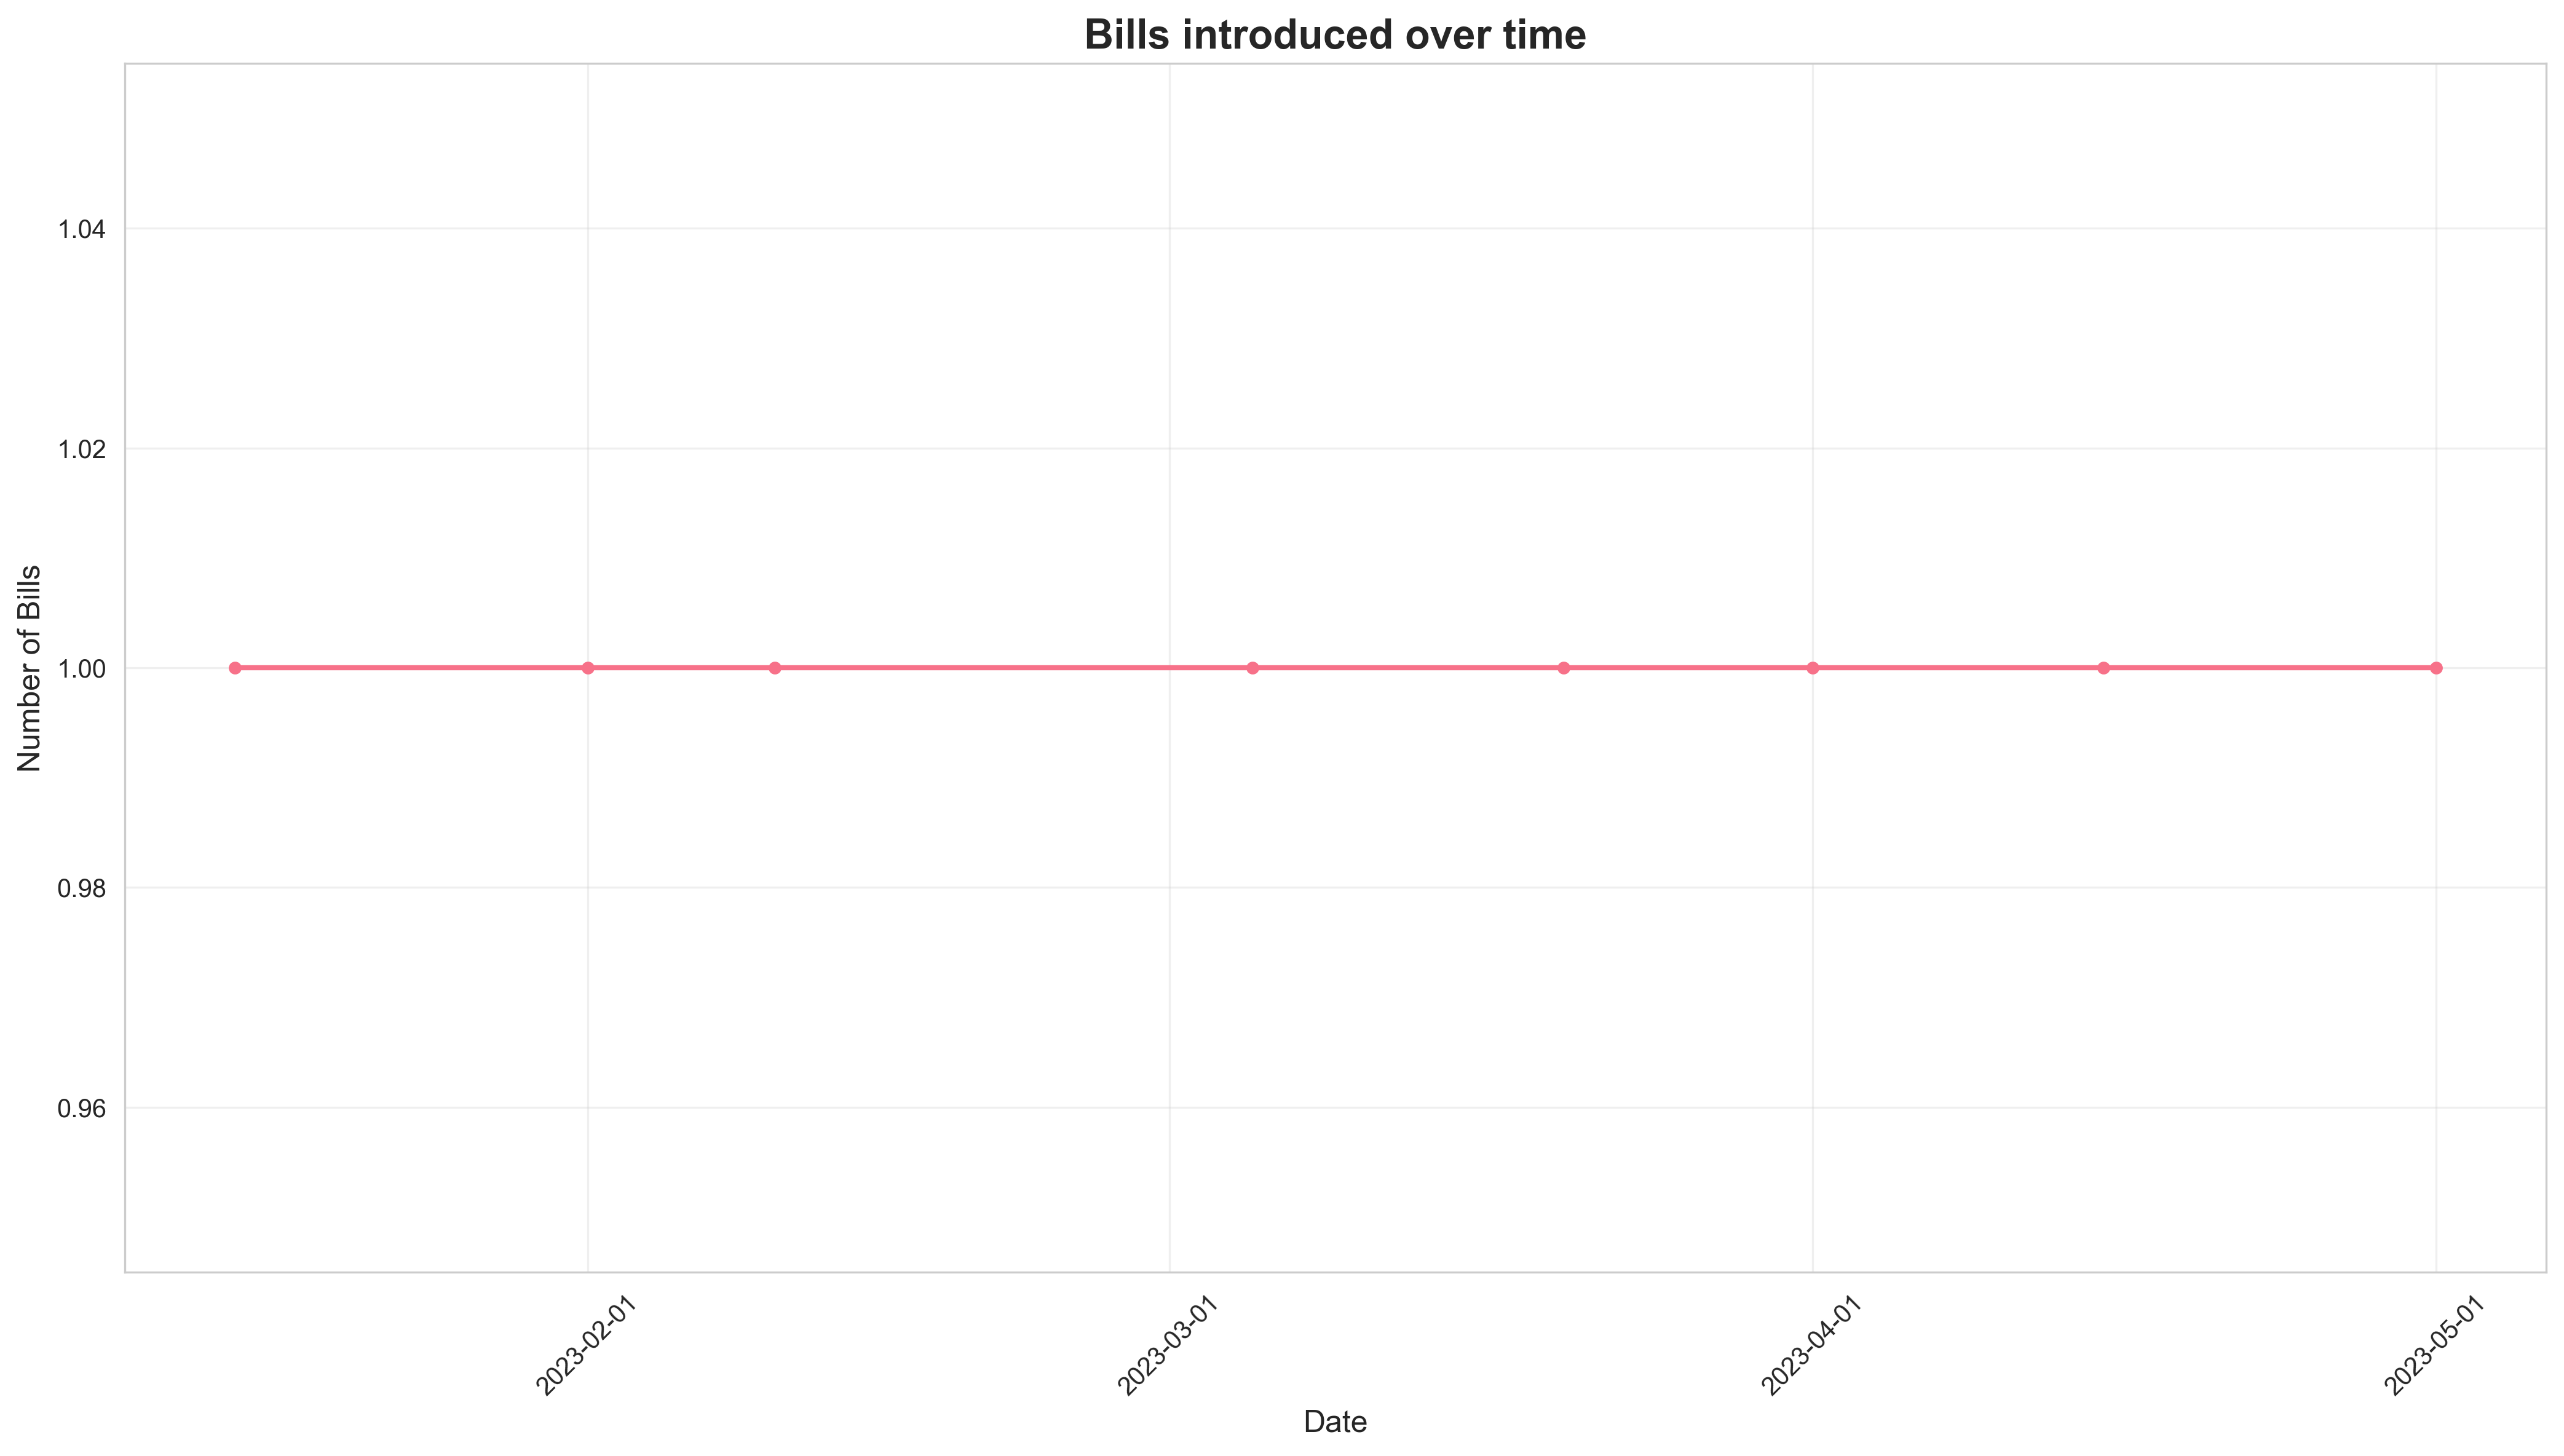

In [5]:
timeline_path = OUTPUT_DIR / "timeline.png"
viz.plot_timeline(bills_df, timeline_path, title="Bills introduced over time")
show_saved(timeline_path)

## Committee activity heatmap

`plot_committee_activity` pivots committee × month counts (uses seaborn when installed).

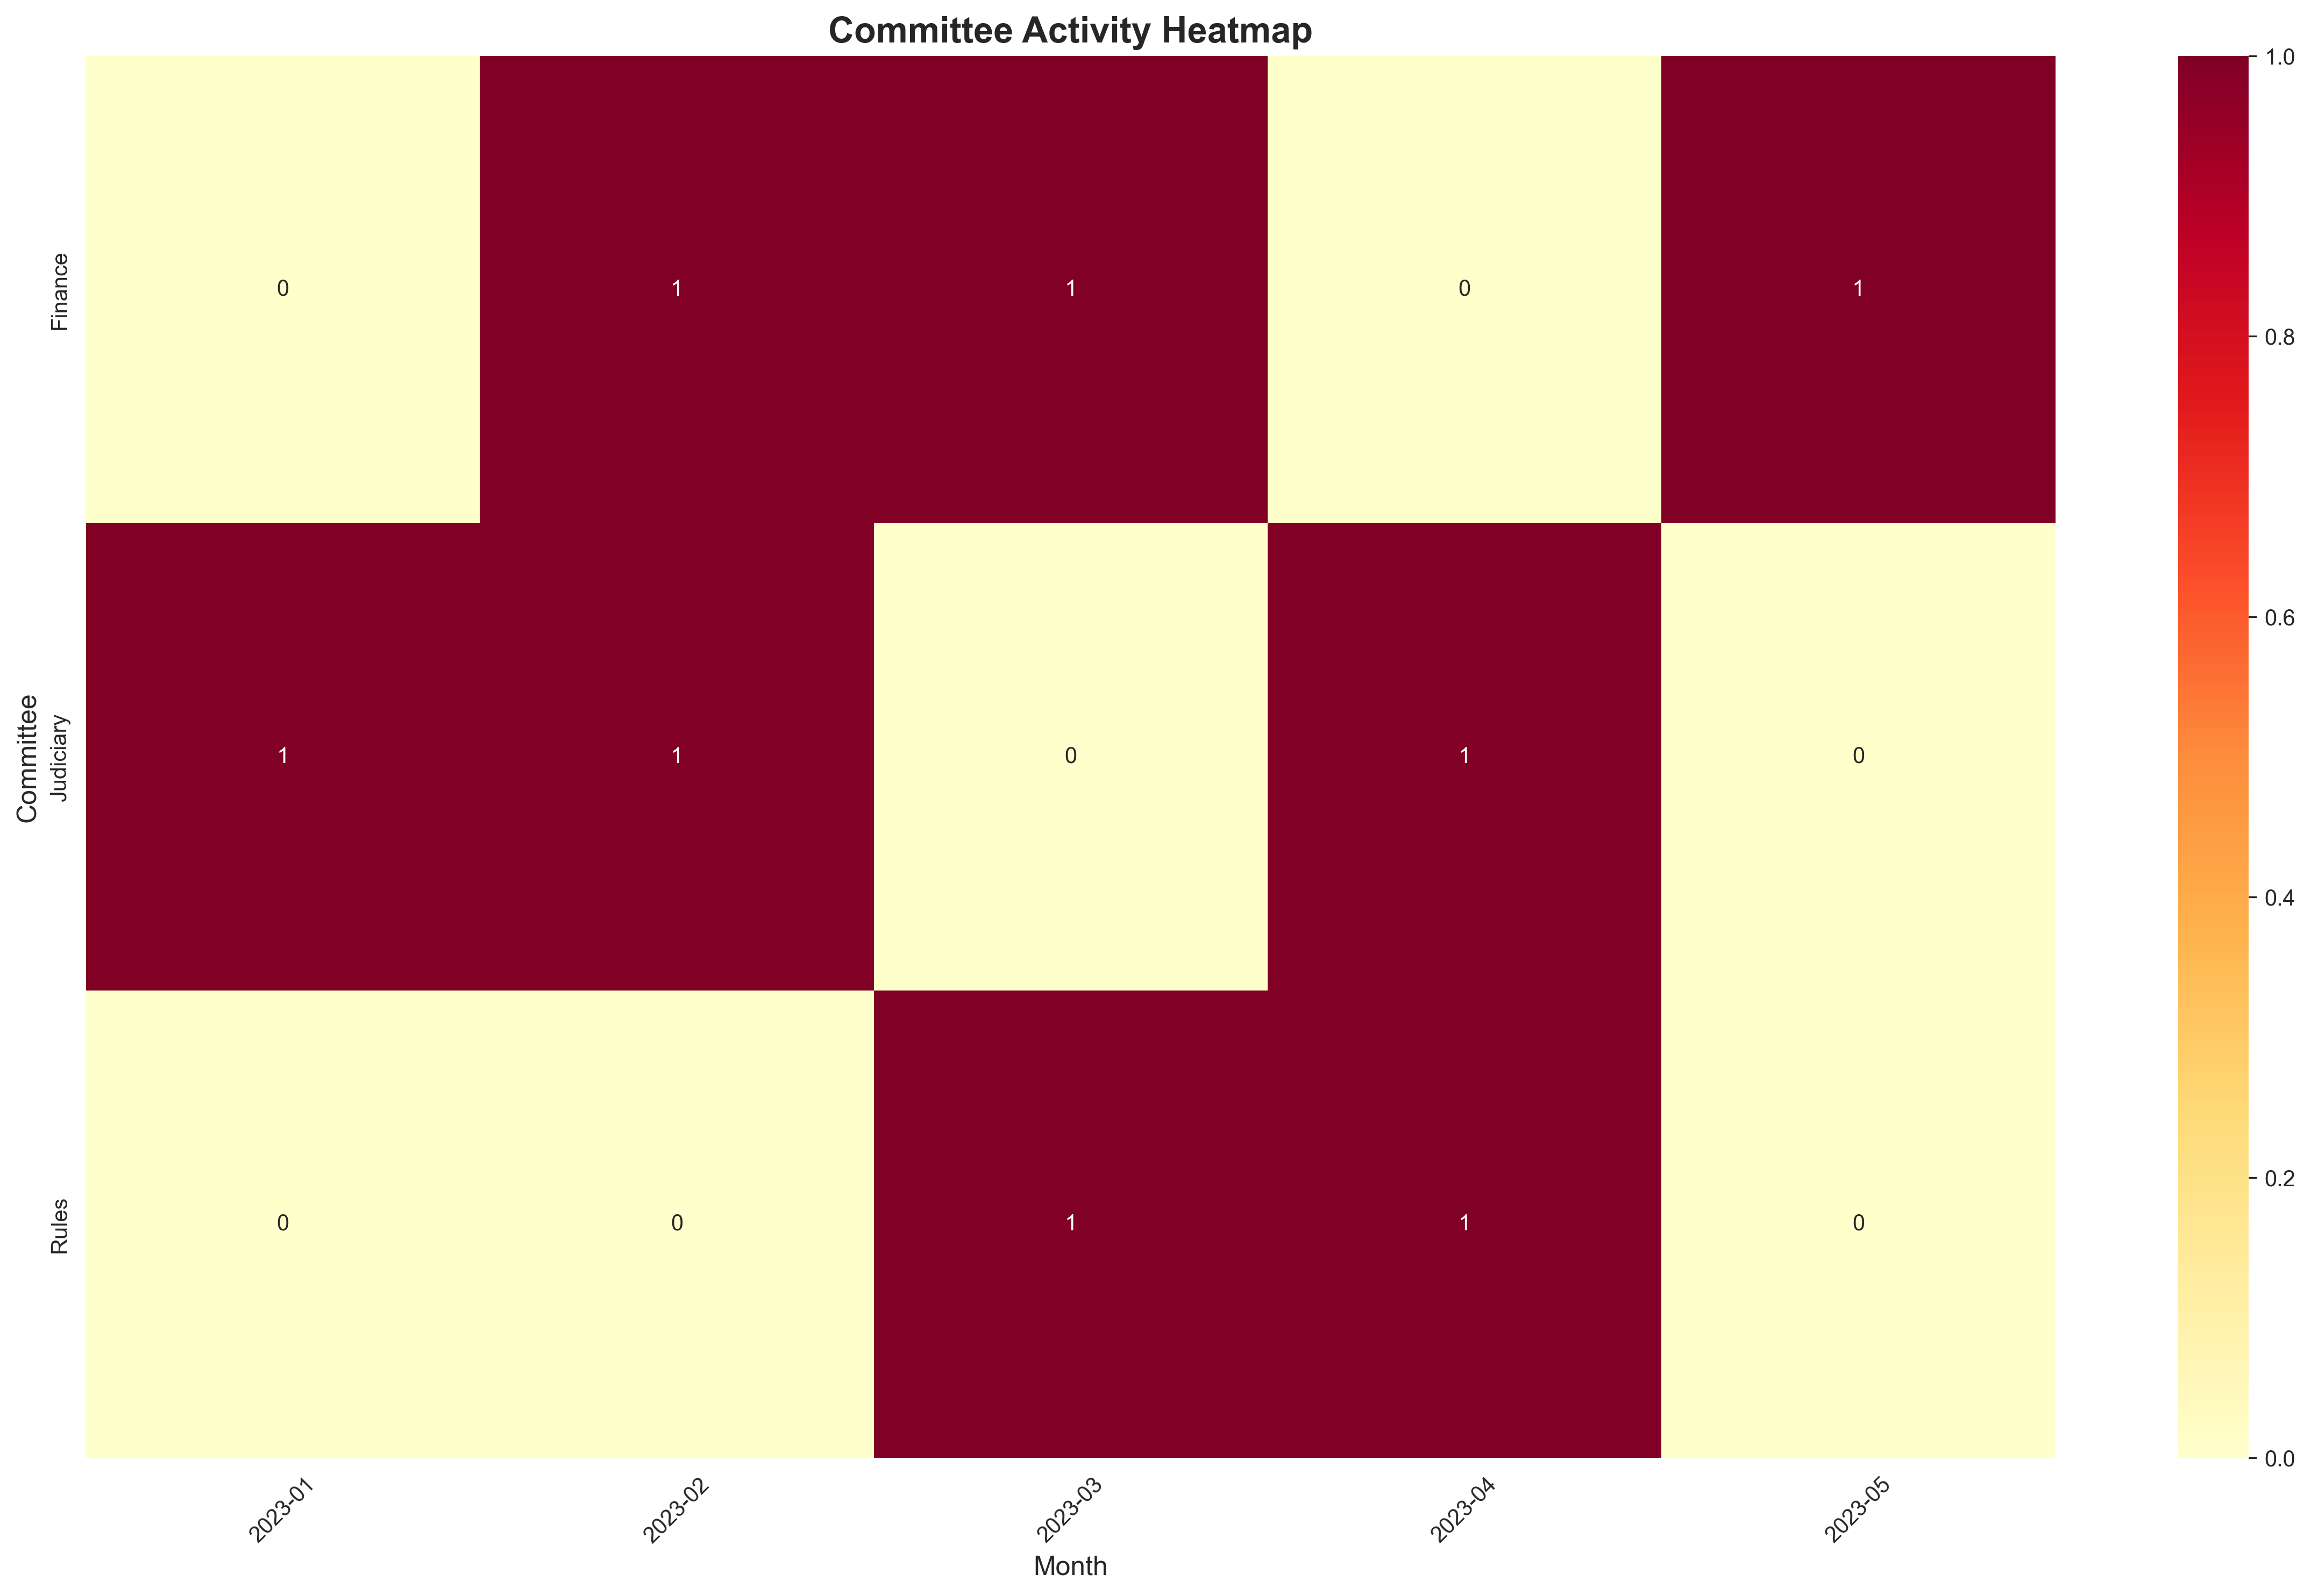

In [6]:
heatmap_path = OUTPUT_DIR / "committee_activity.png"
viz.plot_committee_activity(bills_df, heatmap_path)
show_saved(heatmap_path)

## Member / sponsor activity

`plot_member_activity` counts rows per sponsor (or other `member*` column), top N by default.

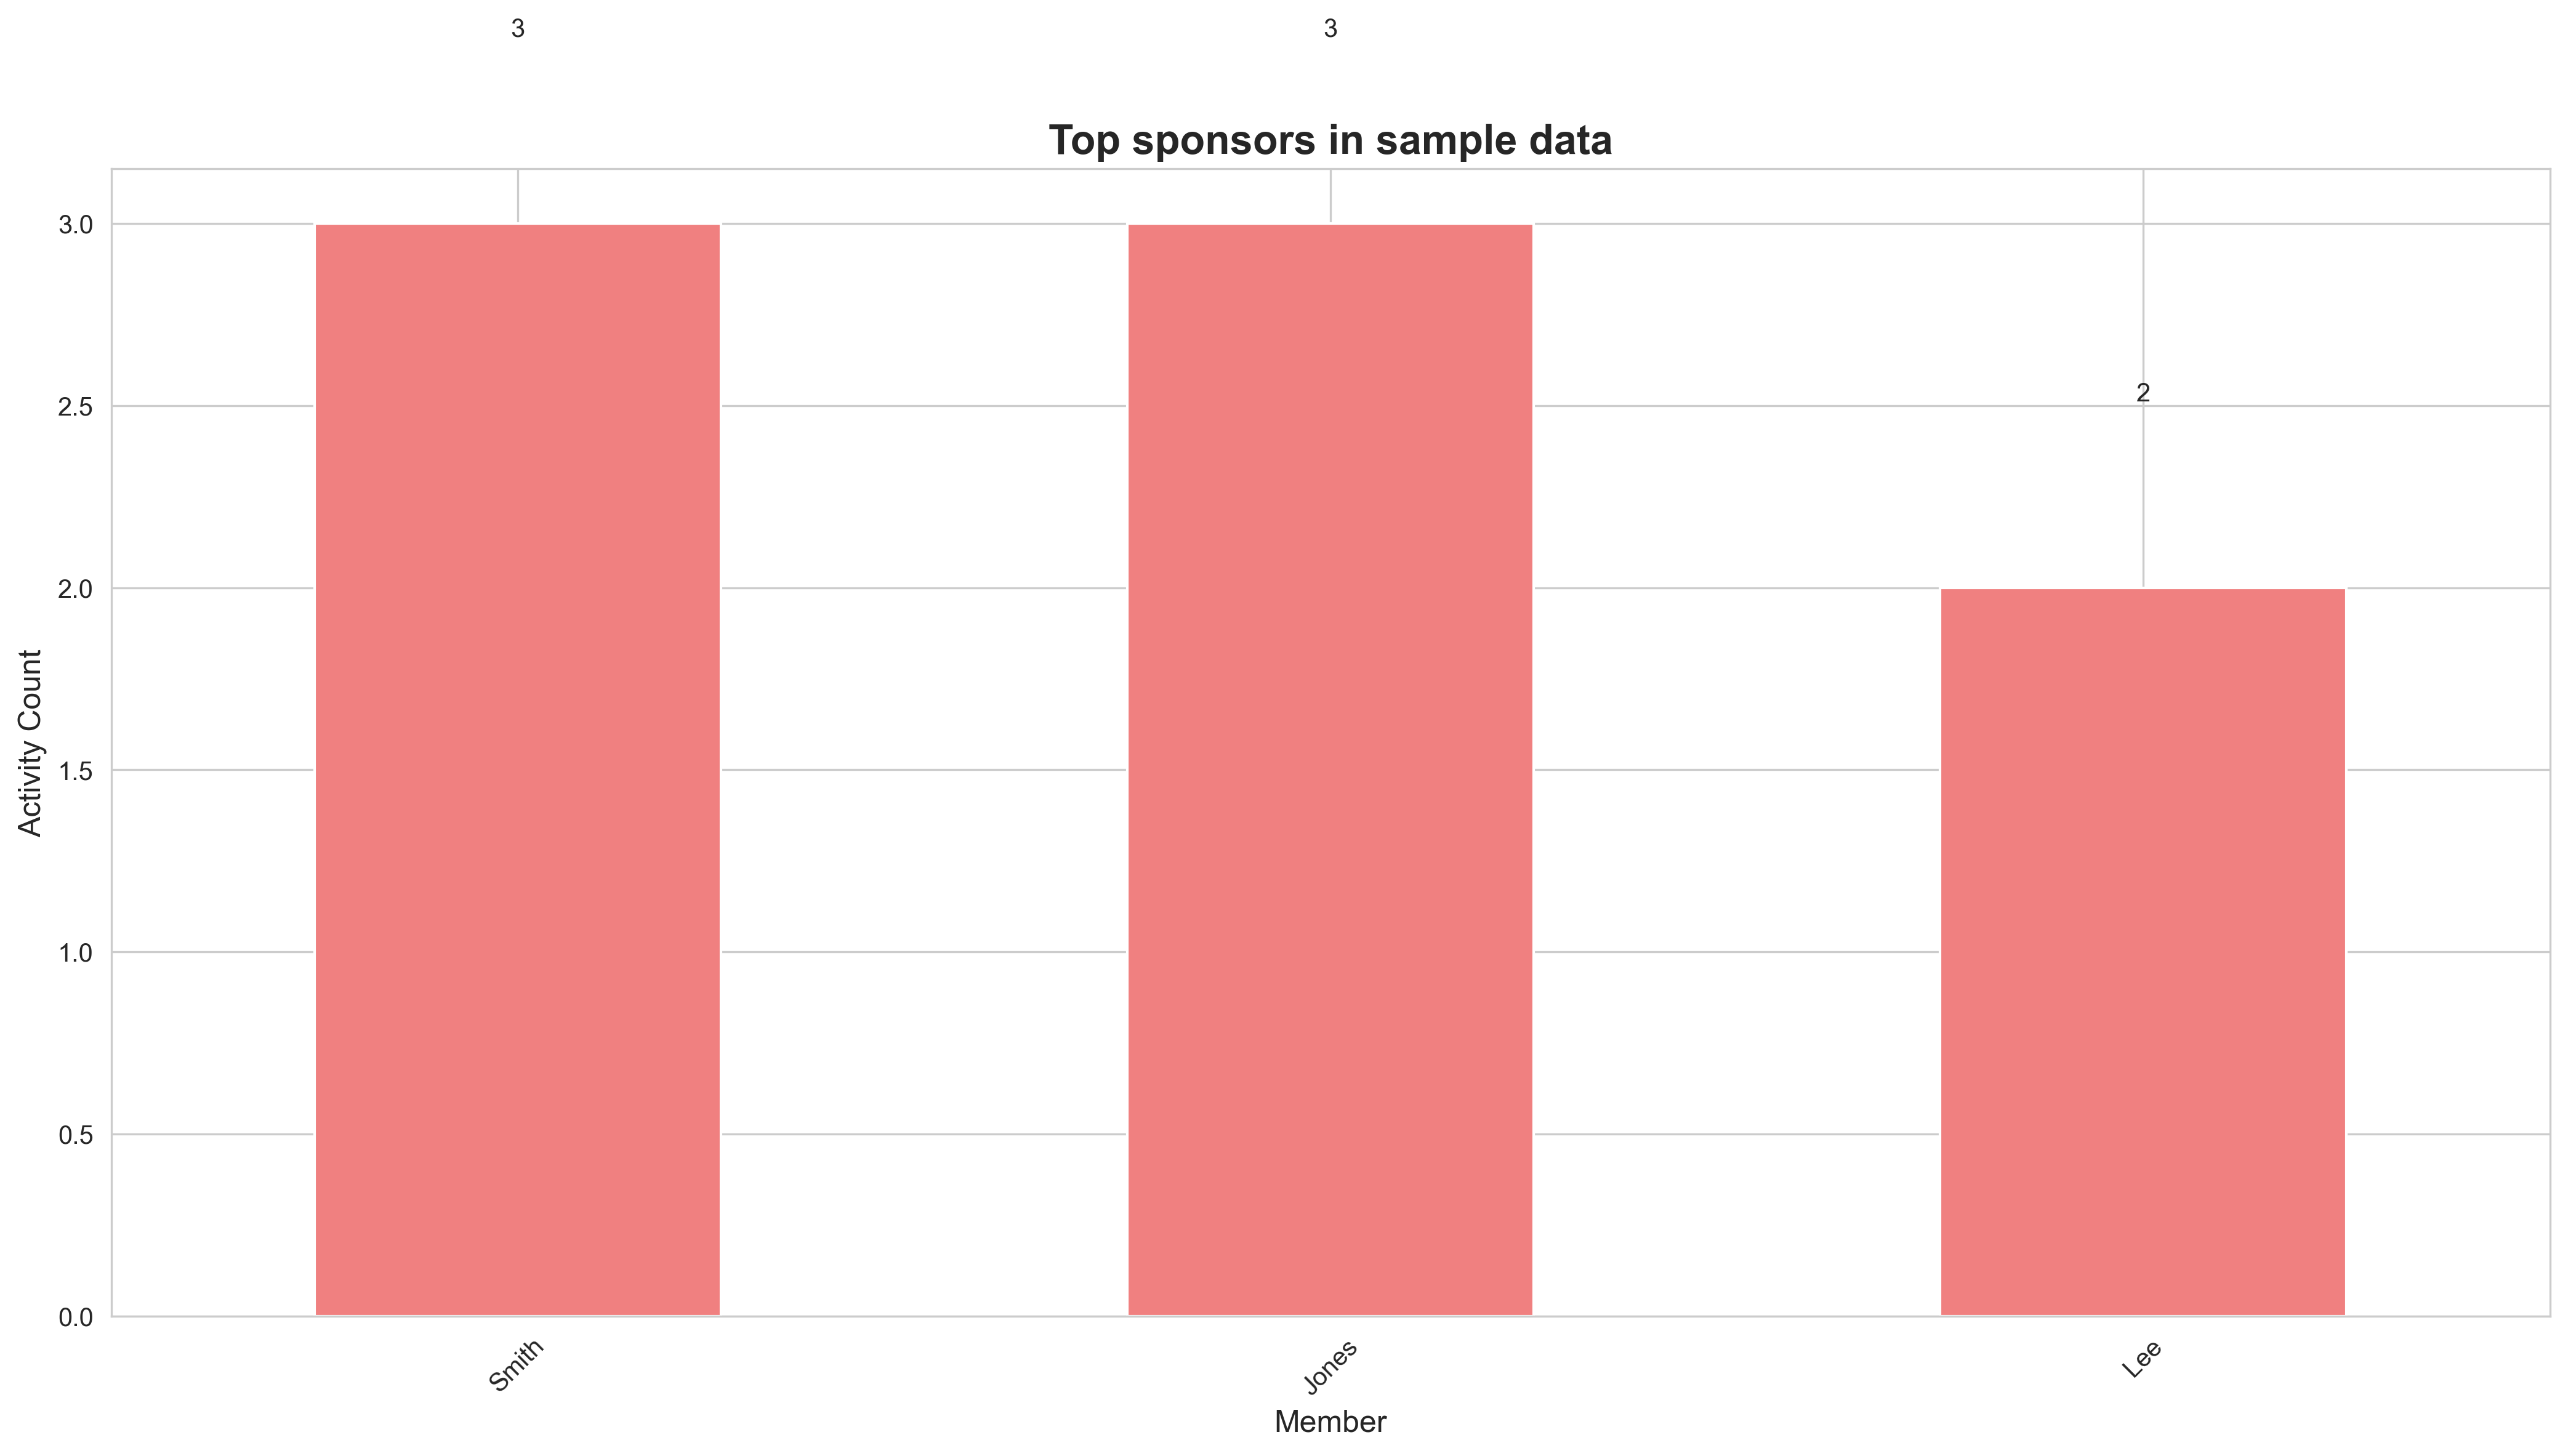

In [7]:
member_path = OUTPUT_DIR / "member_activity.png"
viz.plot_member_activity(bills_df, member_path, top_n=10, title="Top sponsors in sample data")
show_saved(member_path)

## Custom plot

Pass a callable `(df, ax, **kwargs)` to `plot_custom` for charts not built into the exporter.

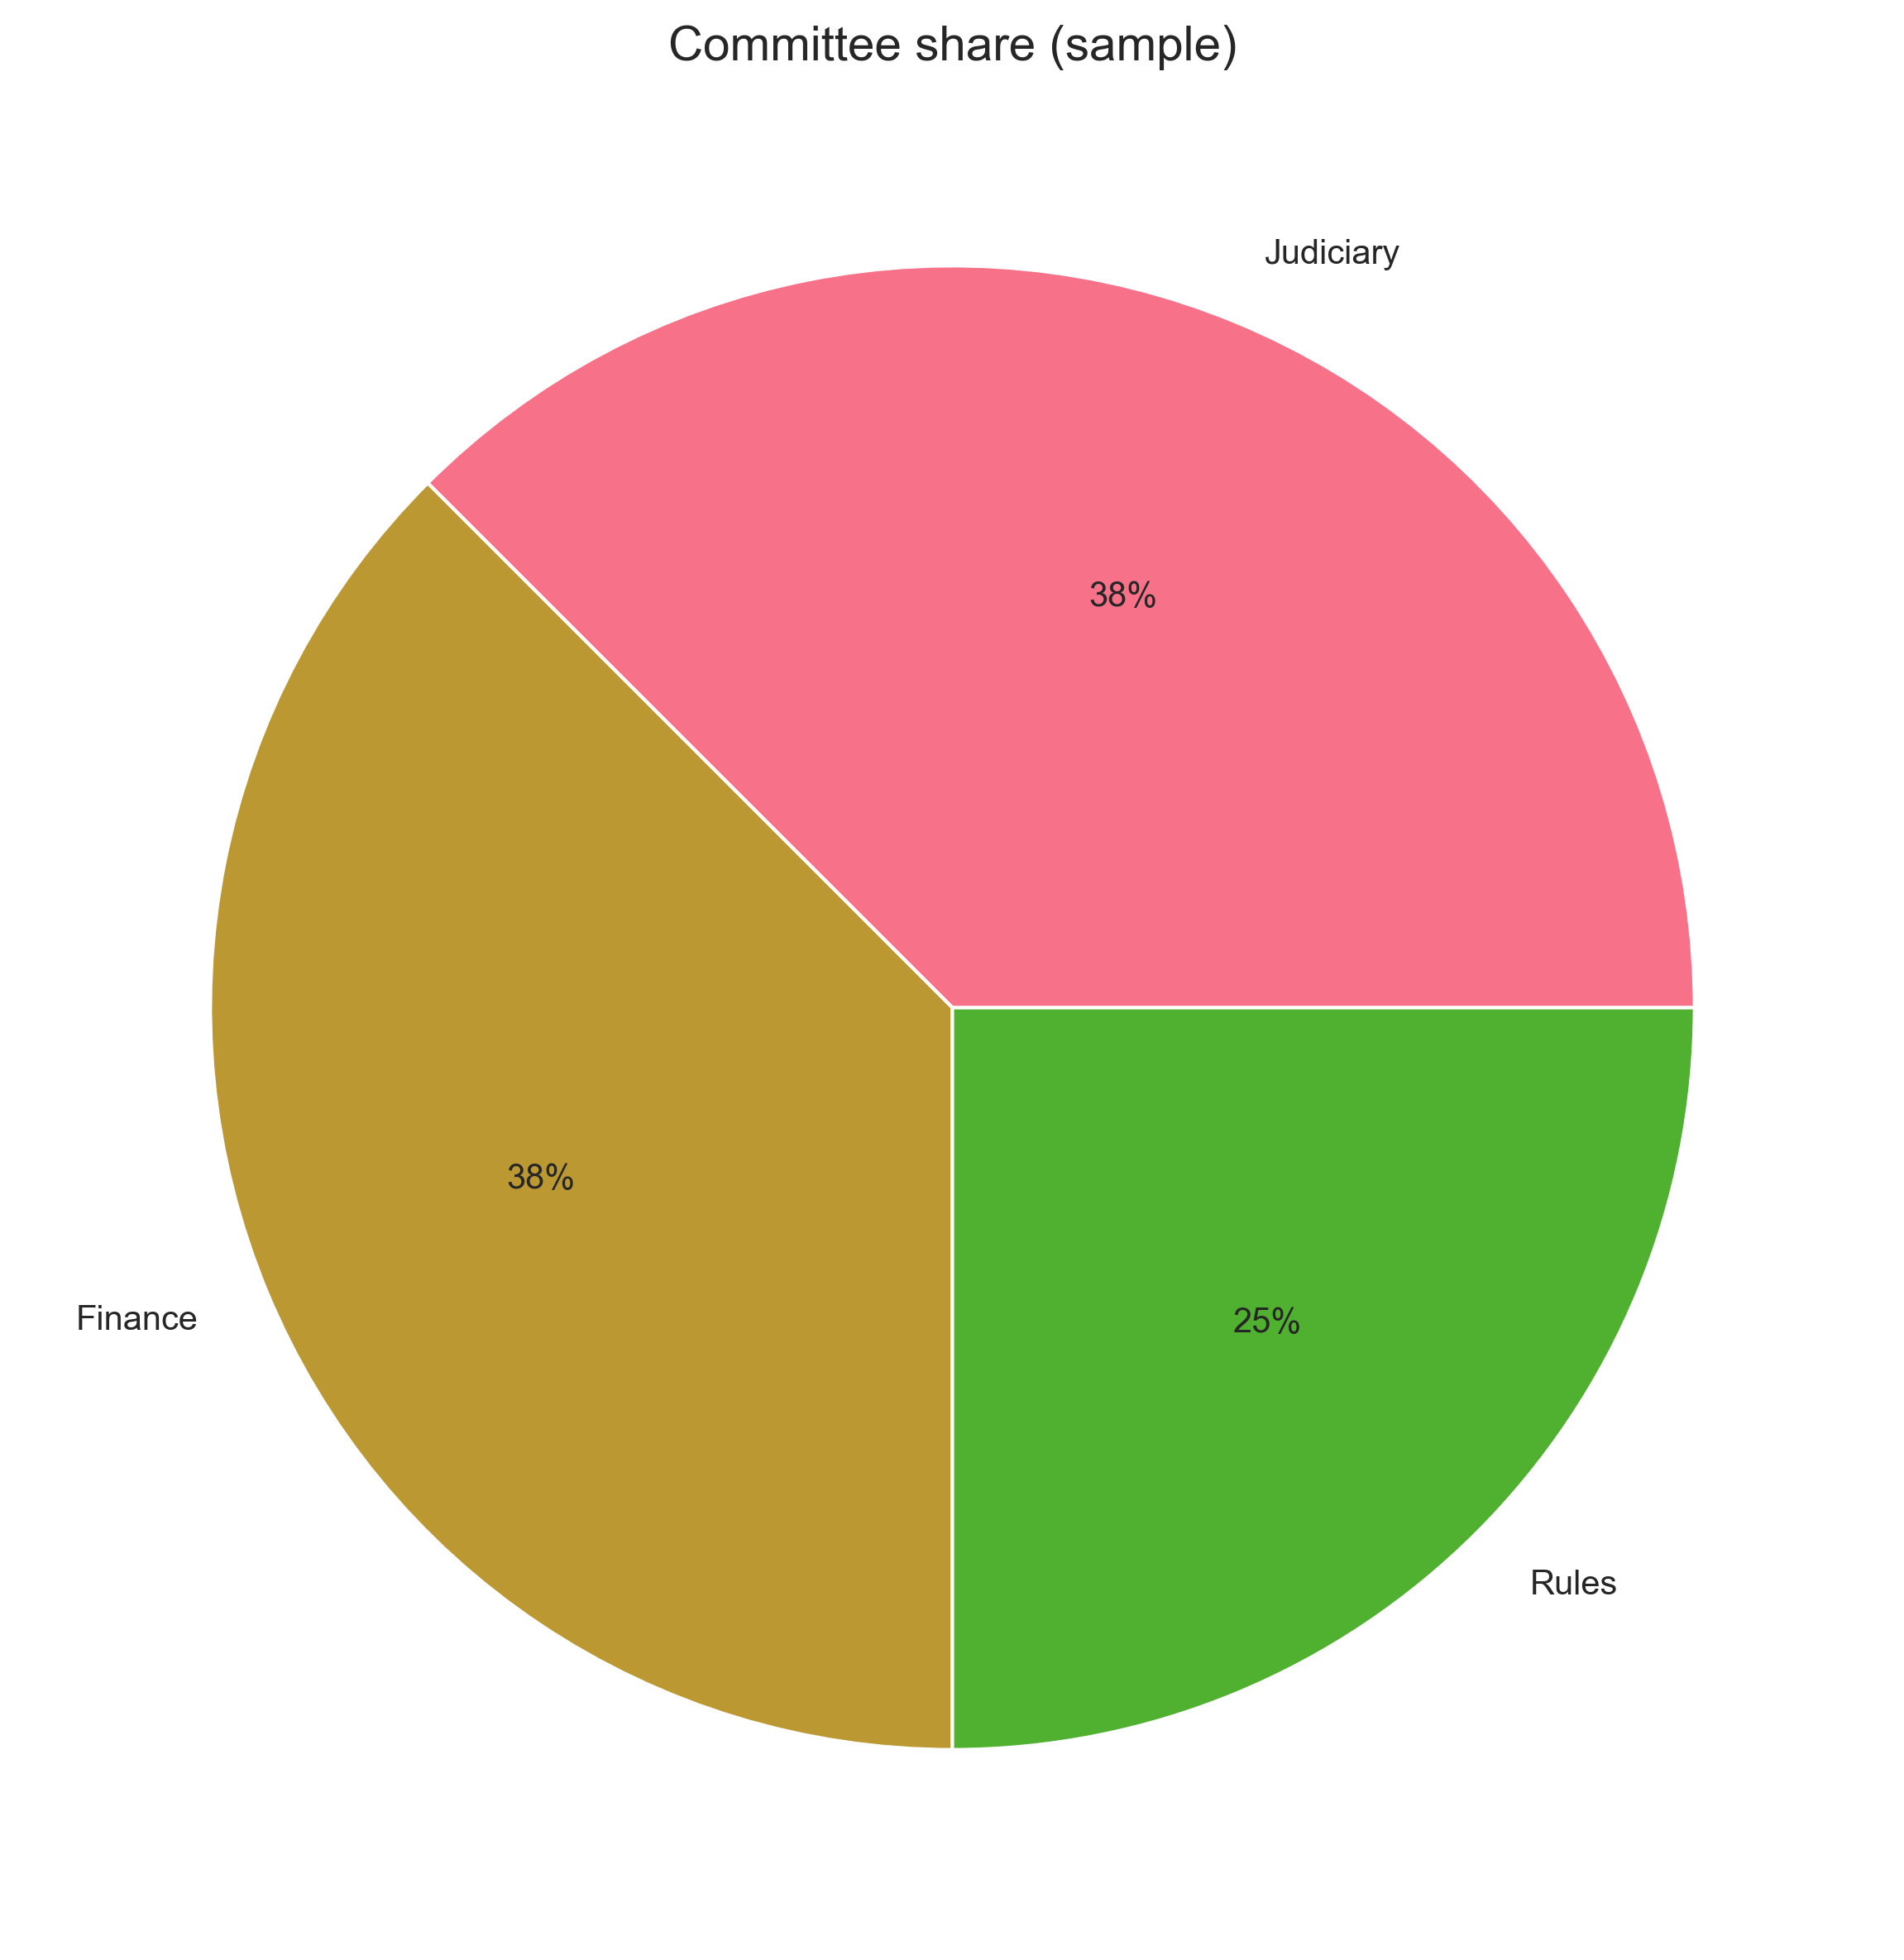

In [8]:
def bills_per_committee(df: pd.DataFrame, ax, **kwargs) -> None:
    counts = df["committee"].value_counts()
    counts.plot(kind="pie", ax=ax, autopct="%1.0f%%")
    ax.set_ylabel("")
    ax.set_title(kwargs.get("title", "Share of bills by committee"))


custom_path = OUTPUT_DIR / "custom_pie.png"
viz.plot_custom(bills_df, custom_path, bills_per_committee, title="Committee share (sample)")
show_saved(custom_path)

## Multi-panel dashboard

`create_dashboard` writes a 2×2 figure (types, timeline, top members, summary text).

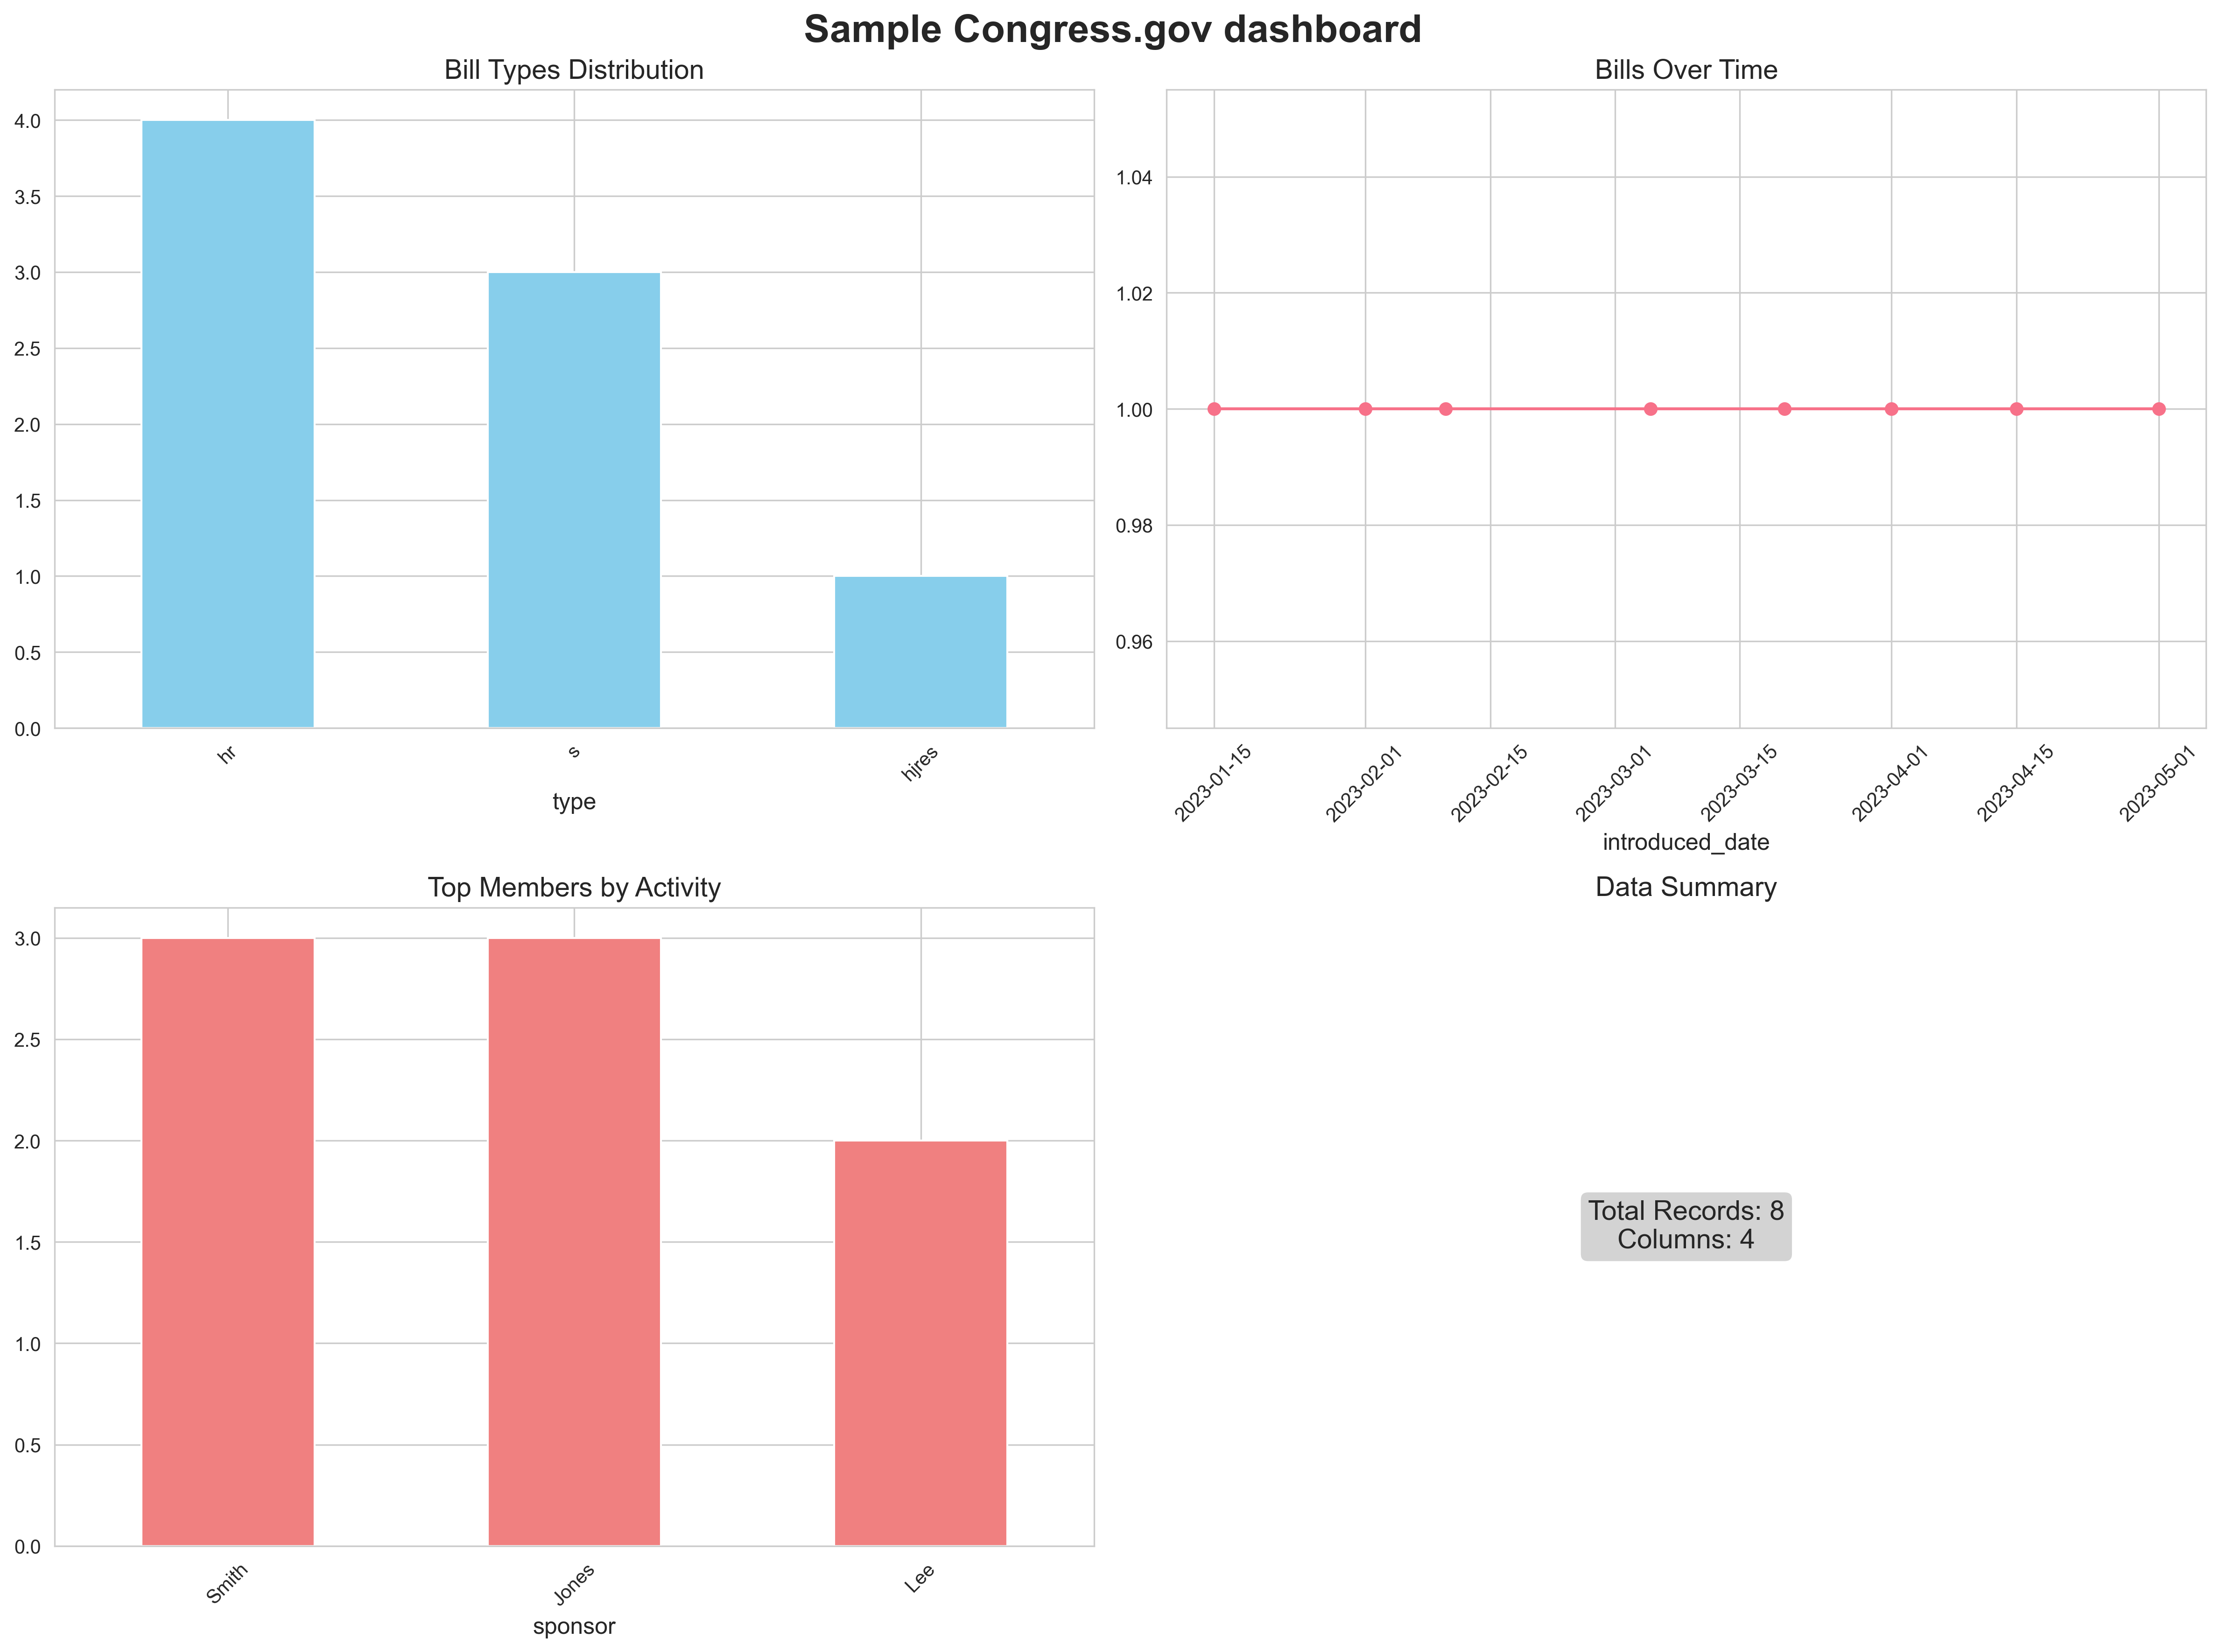

In [9]:
dashboard_path = OUTPUT_DIR / "dashboard.png"
viz.create_dashboard(bills_df, dashboard_path, title="Sample Congress.gov dashboard")
show_saved(dashboard_path, width=1100)

## Styling

Optional seaborn style and palette (no-op for palette if seaborn is missing).

In [10]:
viz.set_style("whitegrid")
viz.set_palette("husl")

## Optional: live API data

With `CONGRESS_API_KEY` set, fetch real bills and pass the collection directly (no manual DataFrame required).

E:\Documents\Code\congressional-data-public\src\congressgov\services\export\pandas_integration.py:280: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(series, errors='raise')
E:\Documents\Code\congressional-data-public\src\congressgov\services\export\pandas_integration.py:280: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(series, errors='raise')
E:\Documents\Code\congressional-data-public\src\congressgov\services\export\pandas_integration.py:280: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(series, errors='raise')
E:\Documents\Cod

,congress,number,type,updateDate,updateDateIncludingText,originChamber,originChamberCode,introducedDate,latestAction_actionDate,latestAction_text,...,laws,notes,policyArea,subjects,summaries,title,titles,amendments,textVersions,url
0,118,1,SRES,2024-04-17,2024-04-17,Senate,S,NaN,2023-01-03,"Submitted in the Senate, considered, and agree...",...,NaN,NaN,NaN,NaN,NaN,A resolution establishing a Committee to Infor...,NaN,NaN,NaN,https://api.congress.gov/v3/bill/118/sres/1?fo...
1,118,3,SRES,2024-04-17,2024-04-17,Senate,S,NaN,2023-01-03,"Submitted in the Senate, considered, and agree...",...,NaN,NaN,NaN,NaN,NaN,"A resolution to elect Patty Murray, a Senator ...",NaN,NaN,NaN,https://api.congress.gov/v3/bill/118/sres/3?fo...
2,118,4,SRES,2025-05-27,2025-05-27,Senate,S,NaN,2023-01-03,"Submitted in the Senate, considered, and agree...",...,NaN,NaN,NaN,NaN,NaN,A resolution notifying the President of the Un...,NaN,NaN,NaN,https://api.congress.gov/v3/bill/118/sres/4?fo...
3,118,6,SRES,2024-04-17,2024-04-17,Senate,S,NaN,2023-01-03,"Submitted in the Senate, considered, and agree...",...,NaN,NaN,NaN,NaN,NaN,A resolution fixing the hour of daily meeting ...,NaN,NaN,NaN,https://api.congress.gov/v3/bill/118/sres/6?fo...
4,118,2,SRES,2024-04-17,2024-04-17,Senate,S,NaN,2023-01-03,Message on Senate action sent to the House.,...,NaN,NaN,NaN,NaN,NaN,A resolution informing the House of Representa...,NaN,NaN,NaN,https://api.congress.gov/v3/bill/118/sres/2?fo...


E:\Documents\Code\congressional-data-public\src\congressgov\services\export\pandas_integration.py:280: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(series, errors='raise')
E:\Documents\Code\congressional-data-public\src\congressgov\services\export\pandas_integration.py:280: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(series, errors='raise')
E:\Documents\Code\congressional-data-public\src\congressgov\services\export\pandas_integration.py:280: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(series, errors='raise')
E:\Documents\Cod

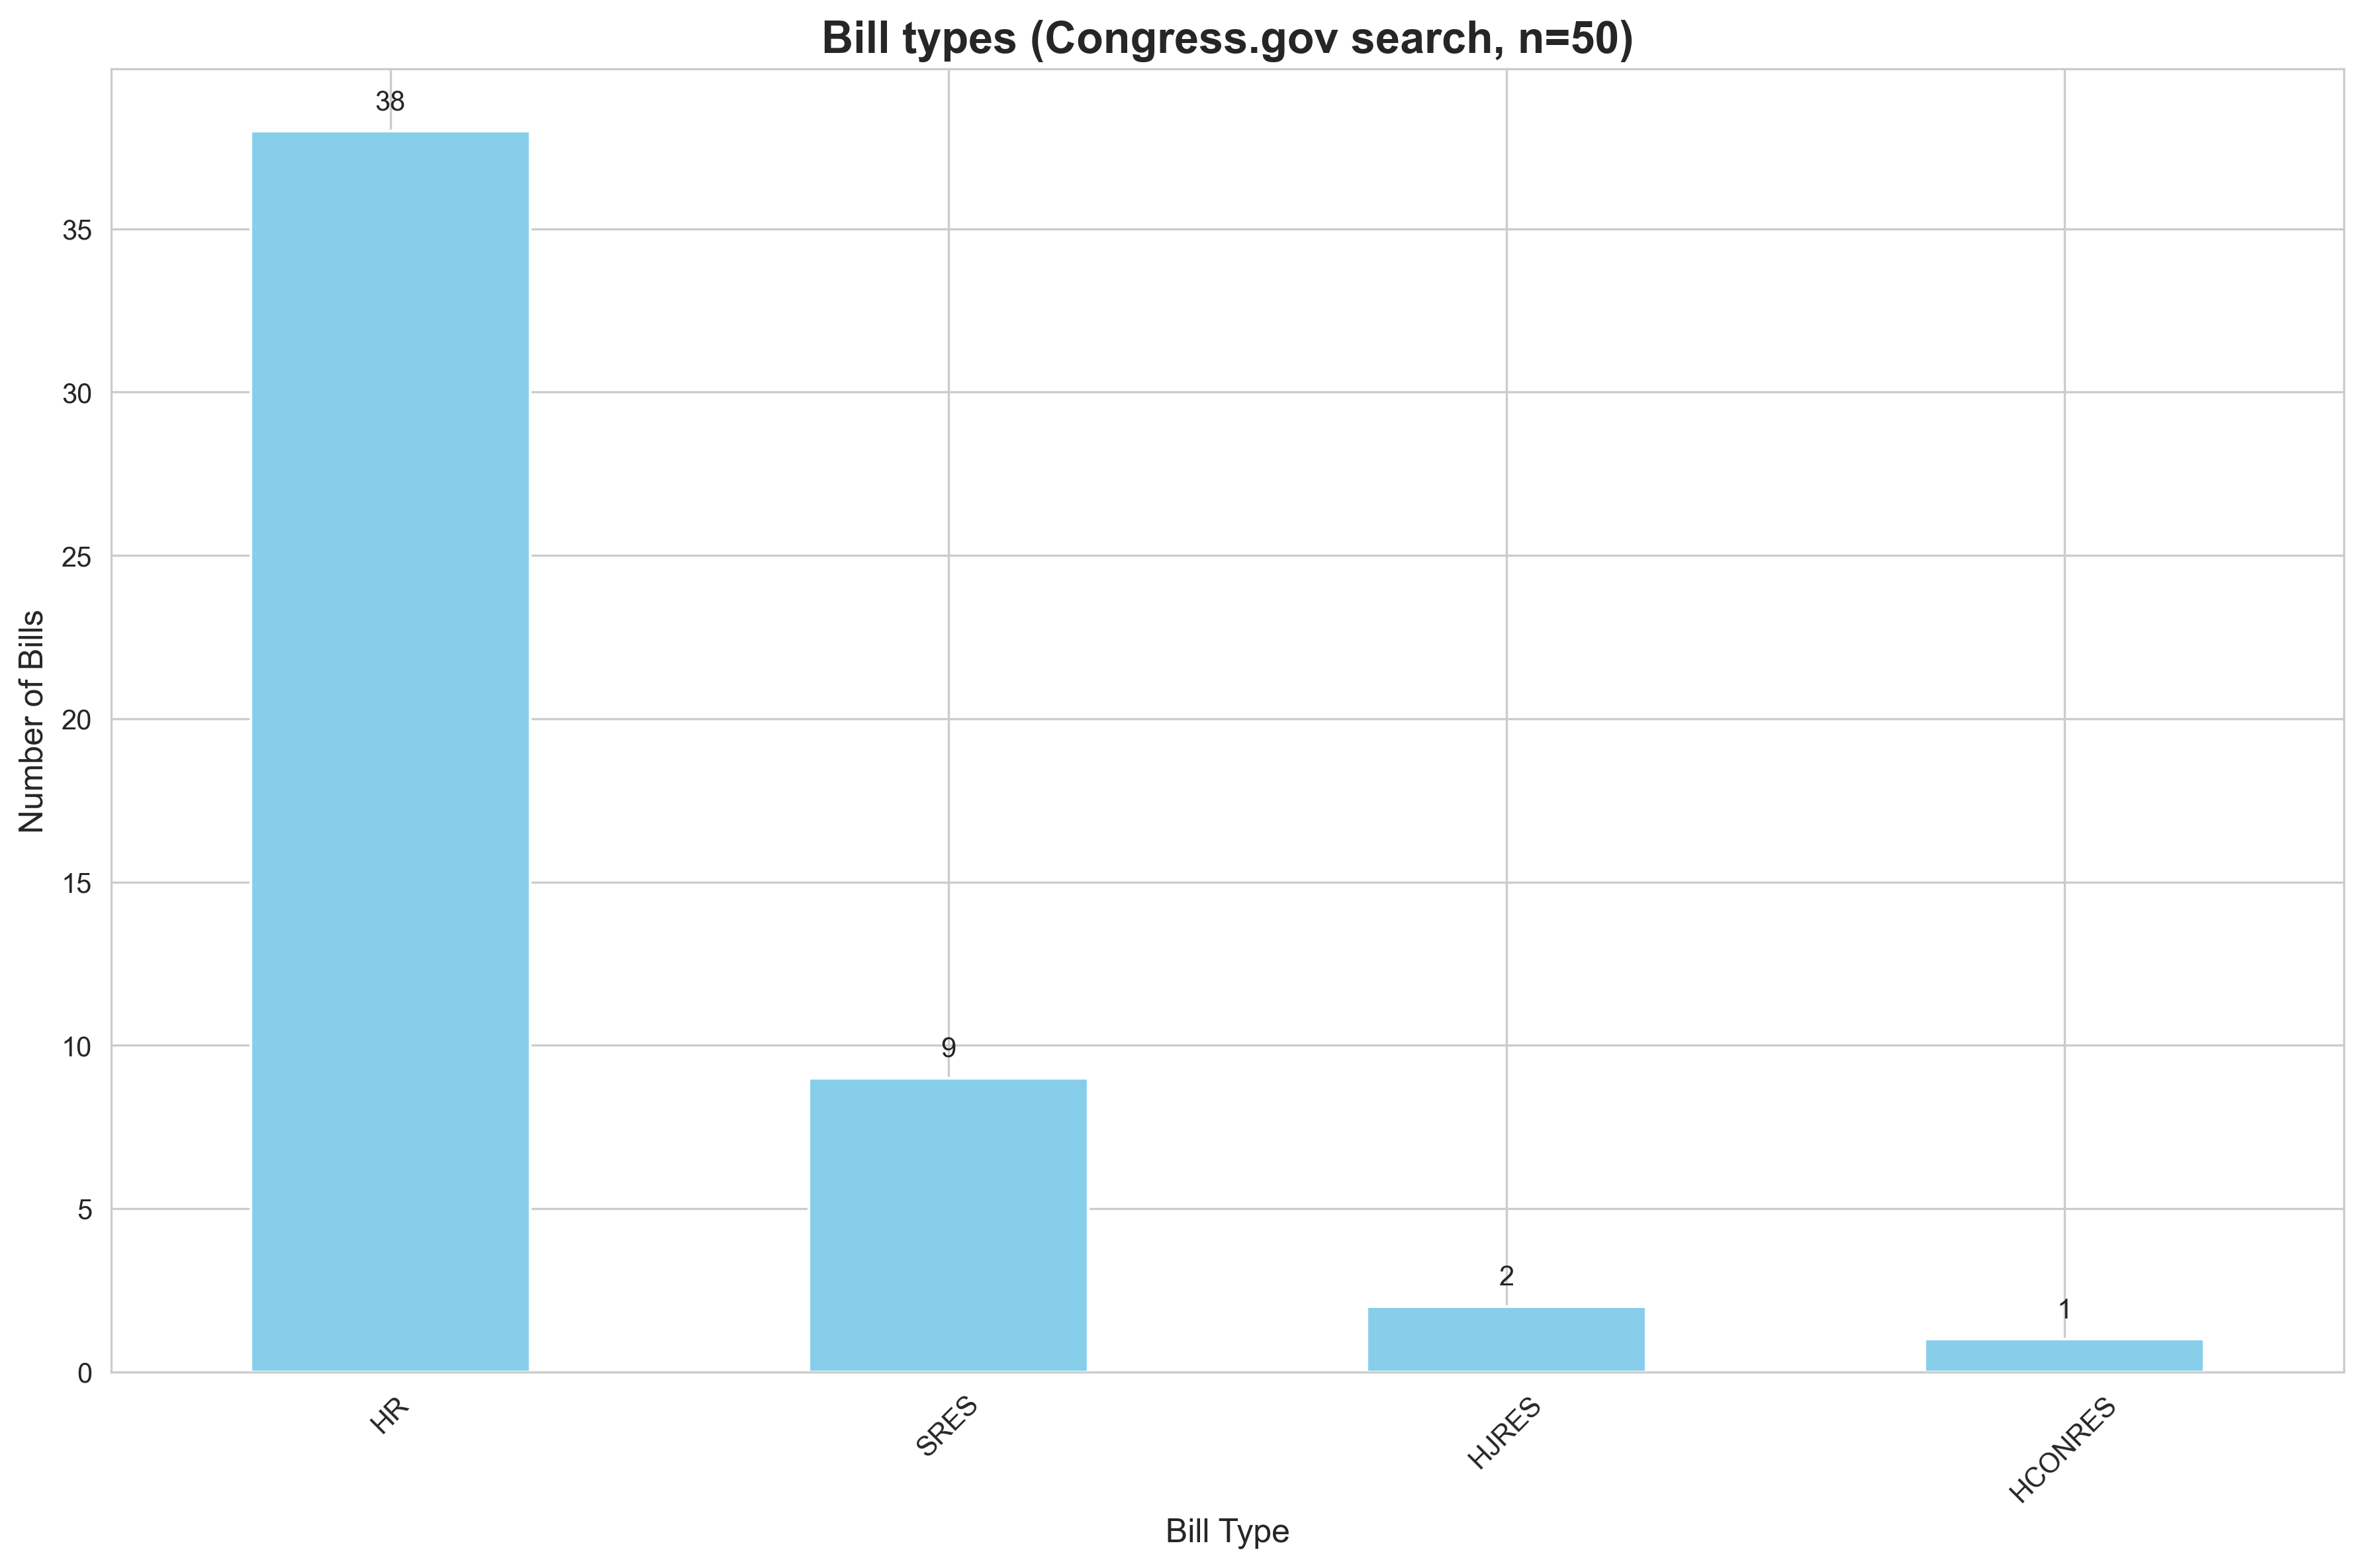

In [11]:
import os

from congressgov import Bill, get_client_from_env
from congressgov.services.export import PandasIntegration

# Ensure .env is loaded so CONGRESS_API_KEY is available in the environment
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass  # If python-dotenv isn't installed, assume env var is already set

api_key = os.environ.get("CONGRESS_API_KEY")
if not api_key:
    print("Skip live API demo: set CONGRESS_API_KEY in a .env file to run this cell.")
else:
    client = get_client_from_env()
    bills = Bill(client=client).search(congress=118, limit=50)

    # Inspect flattened columns before plotting
    preview_df = PandasIntegration(config).to_dataframe(bills)
    display(preview_df.head())

    live_path = OUTPUT_DIR / "live_bill_types.png"
    viz.plot_bill_types(bills, live_path, title="Bill types (Congress.gov search, n=50)")
    show_saved(live_path)